# Error Analysis — What does the CNN get wrong?
Loads the saved checkpoint, re-runs inference on the test set, and examines the
false negatives (missed earthquakes) and false positives (false alarms) in terms
of magnitude, distance, depth, and SNR.

**Run `python data_code/statistics.py` from the project root before this notebook.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_PATH = "best_model.pt"


class EarthquakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

## Load data & run inference

In [2]:
X_spec = np.load("../data/spectrograms/spectrograms_10x10.npy")
X_wave = np.load("../data/waveforms.npy")
meta   = pd.read_csv("../data/metadata.csv", low_memory=False)

X_spec = X_spec[:, np.newaxis, :, :]

# Identical normalisation to training
train_mask = (meta["split"] == "train").values
mu  = float(X_spec[train_mask].mean())
std = float(X_spec[train_mask].std())
X_spec = ((X_spec - mu) / (std + 1e-8)).astype(np.float32)

test_mask   = (meta["split"] == "test").values
X_test      = torch.from_numpy(X_spec[test_mask])
test_labels = meta.loc[test_mask, "label"].values
test_meta   = meta[test_mask].reset_index(drop=True)
test_waves  = X_wave[test_mask]

print(f"Test set: {len(test_labels):,} traces")

Test set: 106,921 traces


In [3]:
model = EarthquakeCNN().to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

loader = DataLoader(TensorDataset(X_test), batch_size=512, shuffle=False)
probs  = []
with torch.no_grad():
    for (batch,) in loader:
        probs.append(torch.sigmoid(model(batch.to(DEVICE))).cpu().numpy())

probs = np.concatenate(probs)
preds = (probs >= 0.5).astype(int)
print("Inference done.")

Inference done.


## Error breakdown

In [4]:
tp = (test_labels == 1) & (preds == 1)
tn = (test_labels == 0) & (preds == 0)
fn = (test_labels == 1) & (preds == 0)   # missed earthquakes
fp = (test_labels == 0) & (preds == 1)   # false alarms

n_eq    = (test_labels == 1).sum()
n_noise = (test_labels == 0).sum()

print(f"Test earthquakes : {n_eq:,}")
print(f"  Caught (TP)    : {tp.sum():,}")
print(f"  Missed (FN)    : {fn.sum():,}  ({100*fn.sum()/n_eq:.2f}% miss rate)")
print()
print(f"Test noise       : {n_noise:,}")
print(f"  Correct (TN)   : {tn.sum():,}")
print(f"  False alarm(FP): {fp.sum():,}  ({100*fp.sum()/n_noise:.2f}% false alarm rate)")

Test earthquakes : 48,333
  Caught (TP)    : 48,207
  Missed (FN)    : 126  (0.26% miss rate)

Test noise       : 58,588
  Correct (TN)   : 58,499
  False alarm(FP): 89  (0.15% false alarm rate)


## Model confidence on errors
How confident was the model on the traces it got wrong?

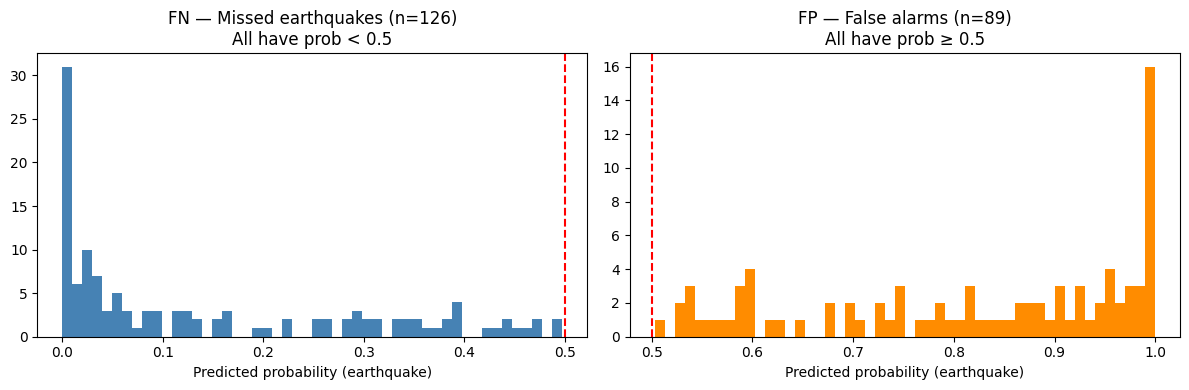

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(probs[fn], bins=50, color="steelblue")
axes[0].set_xlabel("Predicted probability (earthquake)")
axes[0].set_title(f"FN — Missed earthquakes (n={fn.sum():,})\nAll have prob < 0.5")
axes[0].axvline(0.5, color="red", linestyle="--")

axes[1].hist(probs[fp], bins=50, color="darkorange")
axes[1].set_xlabel("Predicted probability (earthquake)")
axes[1].set_title(f"FP — False alarms (n={fp.sum():,})\nAll have prob ≥ 0.5")
axes[1].axvline(0.5, color="red", linestyle="--")

plt.tight_layout()
plt.show()

## FN analysis — missed earthquakes vs caught earthquakes
Do the missed earthquakes have lower magnitude, greater distance, or lower SNR?

In [6]:
fn_meta = test_meta[fn]
tp_meta = test_meta[tp]

cols = [
    ("source_magnitude",   "Magnitude"),
    ("source_distance_km", "Distance (km)"),
    ("source_depth_km",    "Depth (km)"),
    ("snr_db",             "SNR (dB)"),
]

print(f"{'Metric':<22}  {'Caught (TP)':>14}  {'Missed (FN)':>14}")
print("-" * 55)
for col, label in cols:
    tp_vals = pd.to_numeric(tp_meta[col], errors="coerce").dropna()
    fn_vals = pd.to_numeric(fn_meta[col], errors="coerce").dropna()
    if len(fn_vals) == 0:
        continue
    print(f"{label:<22}  {tp_vals.mean():>8.3f} ± {tp_vals.std():.2f}  "
          f"{fn_vals.mean():>8.3f} ± {fn_vals.std():.2f}")

Metric                     Caught (TP)     Missed (FN)
-------------------------------------------------------
Magnitude                  1.281 ± 0.78     1.562 ± 1.02
Distance (km)             41.095 ± 36.75    60.234 ± 63.81
Depth (km)                12.780 ± 15.07    19.345 ± 31.96


C:\Users\tomer\AppData\Local\Temp\claude\ipykernel_8568\3971568621.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tp_vals, fn_vals], labels=["Caught", "Missed"], sym="")
C:\Users\tomer\AppData\Local\Temp\claude\ipykernel_8568\3971568621.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tp_vals, fn_vals], labels=["Caught", "Missed"], sym="")
C:\Users\tomer\AppData\Local\Temp\claude\ipykernel_8568\3971568621.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tp_vals, fn_vals], labels=["Caught", "Missed"], sym="")


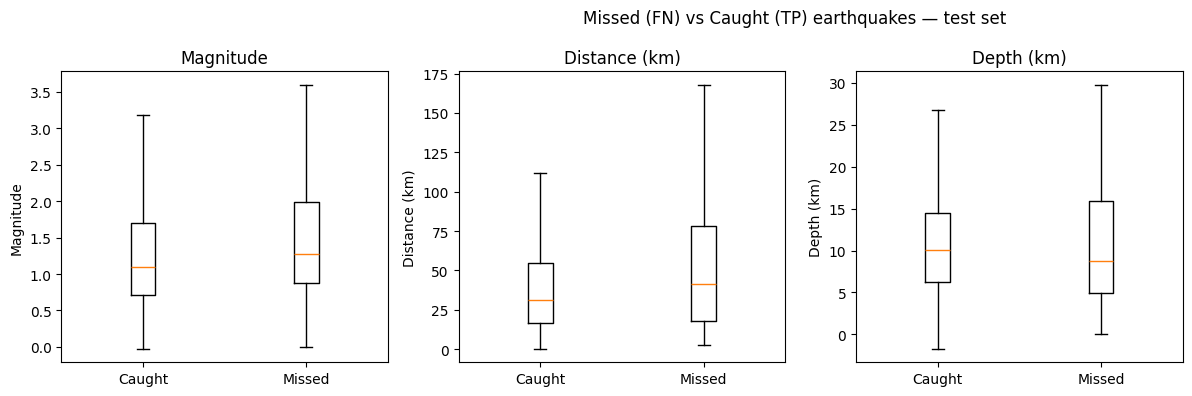

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Missed (FN) vs Caught (TP) earthquakes — test set", fontsize=12)

for ax, (col, label) in zip(axes, cols):
    tp_vals = pd.to_numeric(tp_meta[col], errors="coerce").dropna()
    fn_vals = pd.to_numeric(fn_meta[col], errors="coerce").dropna()
    if len(fn_vals) == 0:
        ax.set_visible(False)
        continue
    ax.boxplot([tp_vals, fn_vals], labels=["Caught", "Missed"], sym="")
    ax.set_title(label)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

## FP analysis — false alarms vs correctly rejected noise

In [8]:
fp_meta = test_meta[fp]
tn_meta = test_meta[tn]

fp_snr = pd.to_numeric(fp_meta["snr_db"], errors="coerce").dropna()
tn_snr = pd.to_numeric(tn_meta["snr_db"], errors="coerce").dropna()

print(f"SNR — False alarms (FP): mean={fp_snr.mean():.3f}  std={fp_snr.std():.3f}")
print(f"SNR — Correct noise (TN): mean={tn_snr.mean():.3f}  std={tn_snr.std():.3f}")

if len(fp_snr) > 0 and len(tn_snr) > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot([tn_snr, fp_snr], labels=["Correct (TN)", "False alarm (FP)"], sym="")
    ax.set_title("SNR — false alarms vs correct noise")
    ax.set_ylabel("SNR (dB)")
    plt.tight_layout()
    plt.show()

SNR — False alarms (FP): mean=nan  std=nan
SNR — Correct noise (TN): mean=nan  std=nan


## Waveform examples
Most confident errors — traces the model was furthest from the decision boundary on.

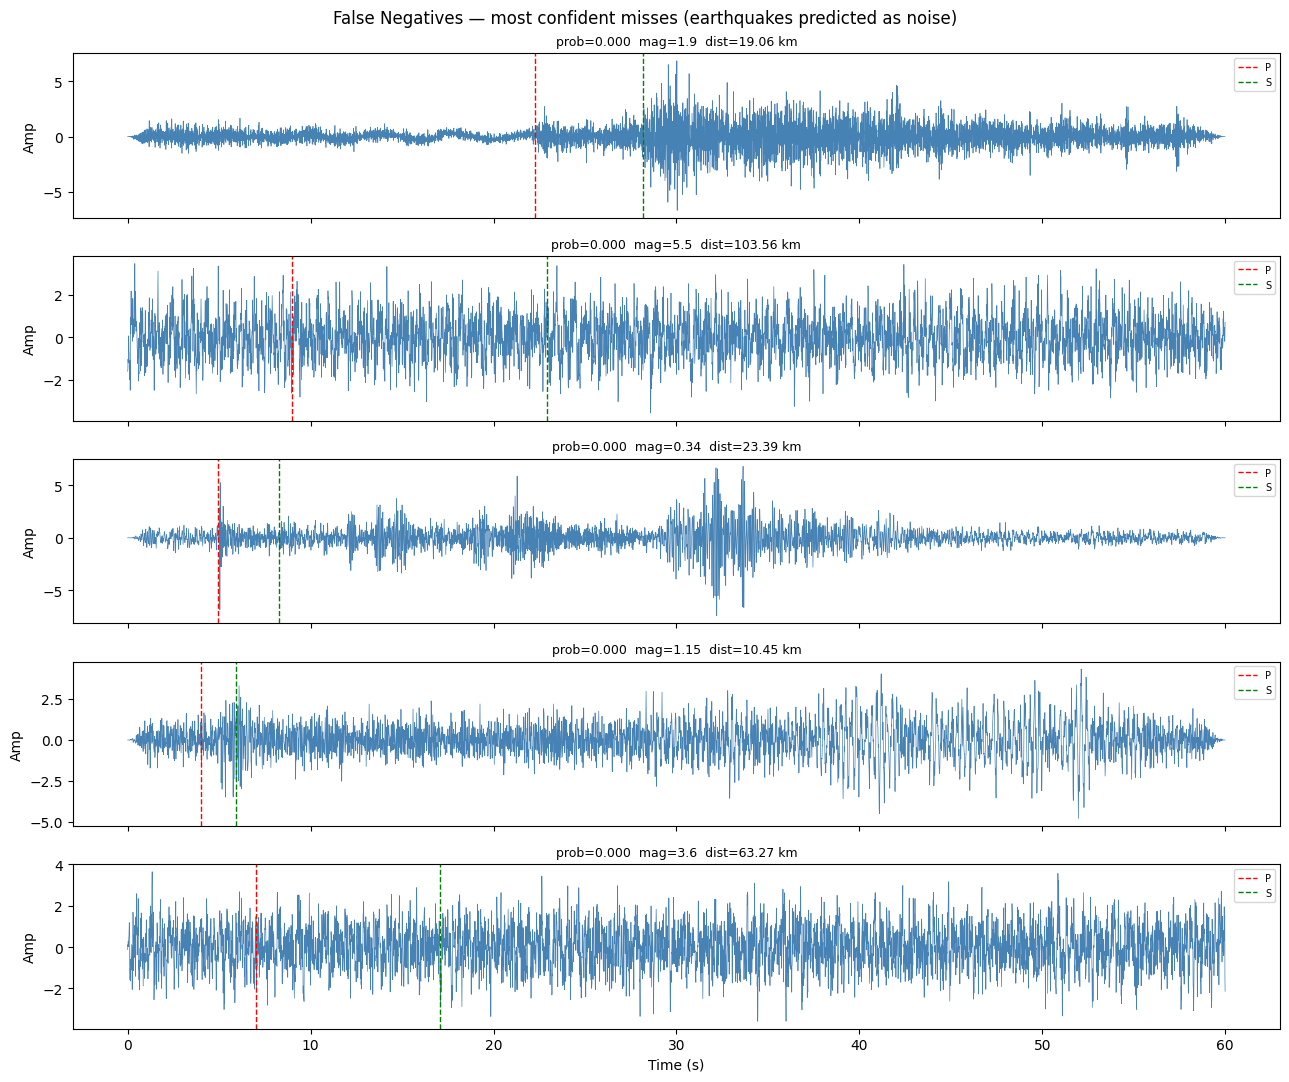

C:\Users\tomer\AppData\Local\Temp\claude\ipykernel_8568\2140569540.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="upper right")


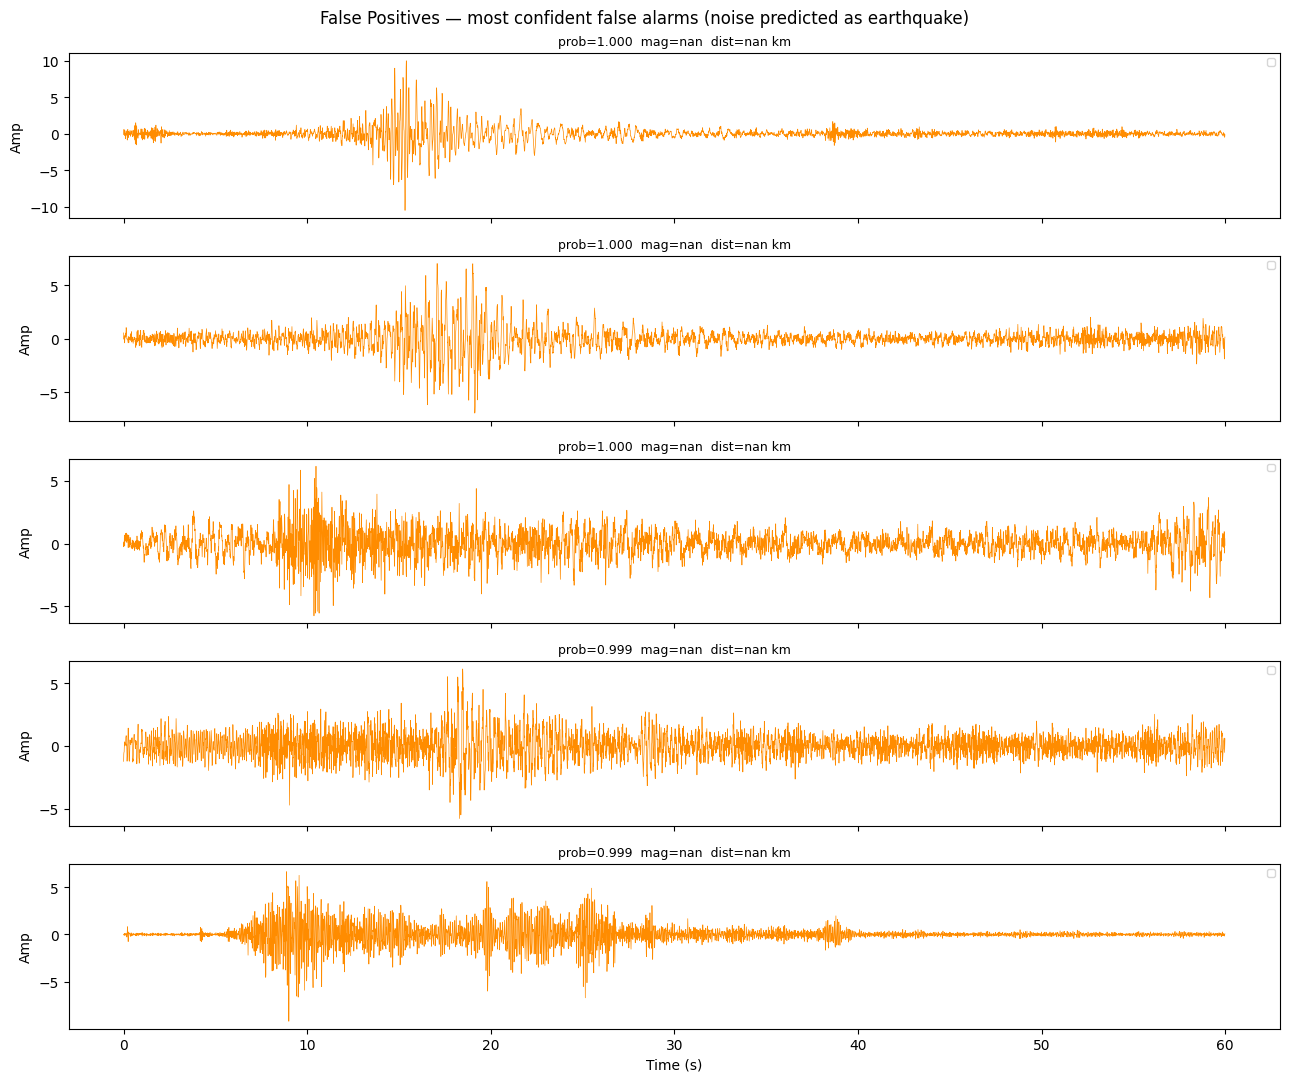

In [9]:
time = np.arange(6000) / 100.0

def plot_examples(mask, title, color, n=5):
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print(f"No {title} examples.")
        return
    # Sort by distance from 0.5 threshold (most confident errors first)
    confidence = np.abs(probs[indices] - 0.5)
    top = indices[np.argsort(confidence)[::-1][:n]]

    fig, axes = plt.subplots(n, 1, figsize=(13, 2.2 * n), sharex=True)
    fig.suptitle(title, fontsize=12)
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, top):
        ax.plot(time, test_waves[idx], lw=0.5, color=color)
        row = test_meta.iloc[idx]
        p_arr = row.get("p_arrival_sample", None)
        s_arr = row.get("s_arrival_sample", None)
        if pd.notna(p_arr): ax.axvline(float(p_arr)/100, color="red",   lw=1, ls="--", label="P")
        if pd.notna(s_arr): ax.axvline(float(s_arr)/100, color="green", lw=1, ls="--", label="S")
        mag  = row.get("source_magnitude", "?")
        dist = row.get("source_distance_km", "?")
        ax.set_title(
            f"prob={probs[idx]:.3f}  mag={mag}  dist={dist} km",
            fontsize=9
        )
        ax.set_ylabel("Amp")
        ax.legend(fontsize=7, loc="upper right")
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_examples(fn, "False Negatives — most confident misses (earthquakes predicted as noise)", "steelblue")
plot_examples(fp, "False Positives — most confident false alarms (noise predicted as earthquake)", "darkorange")

## Compare to overall dataset statistics

In [10]:
try:
    with open("../data/statistics.json") as f:
        overall = json.load(f)
    print("Overall dataset (all splits):")
    for key in ("magnitude", "distance_km", "depth_km", "snr_db"):
        v = overall.get(key)
        if v:
            print(f"  {key:<15} mean={v['mean']:.3f}  median={v['median']:.3f}  std={v['std']:.3f}")
    print()
    print("Missed earthquakes (FN) on test set:")
    for col, label in cols:
        vals = pd.to_numeric(fn_meta[col], errors="coerce").dropna()
        if len(vals) > 0:
            print(f"  {label:<22} mean={vals.mean():.3f}  median={vals.median():.3f}  std={vals.std():.3f}")
except FileNotFoundError:
    print("statistics.json not found — run: python data_code/statistics.py")

Overall dataset (all splits):
  magnitude       mean=1.273  median=1.100  std=0.779
  distance_km     mean=40.771  median=31.170  std=36.270
  depth_km        mean=12.792  median=10.100  std=15.033

Missed earthquakes (FN) on test set:
  Magnitude              mean=1.562  median=1.270  std=1.021
  Distance (km)          mean=60.234  median=41.610  std=63.810
  Depth (km)             mean=19.345  median=8.760  std=31.965
